<a href="https://colab.research.google.com/github/DimiGretsistas/Automated-Customers-Reviews-Project/blob/main/notebooks/04_summarization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Summarization

**Goals**
- Use a small generative model to create short recommendation articles from clustered product reviews.
- This notebook recreates the clustered sample directly, so it does not depend on the clustering notebook.

In [1]:
import pandas as pd

#load cleaned dataset from Colab
df = pd.read_csv(
    "/content/clean_reviews.csv",
    engine="python",
    on_bad_lines="skip"
)

# inspect data
df.head()

,name,reviews.rating,reviews.text,sentiment,clean_review
0,AmazonBasics AAA Performance Alkaline Batterie...,3,I order 3 of them and one of the item is bad q...,neutral,i order 3 of them and one of the item is bad q...
1,AmazonBasics AAA Performance Alkaline Batterie...,4,Bulk is always the less expensive way to go fo...,positive,bulk is always the less expensive way to go fo...
2,AmazonBasics AAA Performance Alkaline Batterie...,5,Well they are not Duracell but for the price i...,positive,well they are not duracell but for the price i...
3,AmazonBasics AAA Performance Alkaline Batterie...,5,Seem to work as well as name brand batteries a...,positive,seem to work as well as name brand batteries a...
4,AmazonBasics AAA Performance Alkaline Batterie...,5,These batteries are very long lasting the pric...,positive,these batteries are very long lasting the pric...


## Create Sample for Summarization
- Using a smaller sample to keep the notebook fast.

In [2]:
#use a smaller sample for fast processing
sample_df = df.sample(n=1000, random_state=42).copy()

#check sample size
sample_df.shape

(1000, 5)

## Create Embeddings and Clusters
- Using a pretrained sentence transformer and KMeans to recreate product clusters.

In [3]:
!pip install sentence-transformers -q

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

#prepare review texts
texts = sample_df["clean_review"].tolist()

#load embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

#create embeddings
embeddings = embedding_model.encode(texts, show_progress_bar=True)

#create 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)

#assign clusters
sample_df["cluster"] = kmeans.fit_predict(embeddings)

sample_df[["name", "clean_review", "cluster"]].head()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

,name,clean_review,cluster
2595,AmazonBasics AAA Performance Alkaline Batterie...,no problems with purchase,0
3984,AmazonBasics AAA Performance Alkaline Batterie...,good long lasting batteries at a fair price,1
6137,AmazonBasics AAA Performance Alkaline Batterie...,i ve been ordering these since amazon started ...,3
6479,AmazonBasics AAA Performance Alkaline Batterie...,batteries these amazon basics aaas actually ha...,3
39,AmazonBasics AAA Performance Alkaline Batterie...,these batteries are horrible we depend on aa b...,1


## Inspect Clustered Sample
- Checking available clusters and products in the sampled data.

In [4]:
#check sample dataset size
print(sample_df.shape)

#check available clusters
print(sample_df["cluster"].value_counts())

#inspect clustered sample
sample_df[["name", "reviews.rating", "sentiment", "cluster"]].head()

(1000, 6)
cluster
1    331
3    226
4    150
2    148
0    145
Name: count, dtype: int64


,name,reviews.rating,sentiment,cluster
2595,AmazonBasics AAA Performance Alkaline Batterie...,5,positive,0
3984,AmazonBasics AAA Performance Alkaline Batterie...,5,positive,1
6137,AmazonBasics AAA Performance Alkaline Batterie...,5,positive,3
6479,AmazonBasics AAA Performance Alkaline Batterie...,5,positive,3
39,AmazonBasics AAA Performance Alkaline Batterie...,1,negative,1


## Prepare Product Insights
- Extracting top products, worst product, and complaints per cluster.

In [5]:
def prepare_cluster_insights(cluster_df):
    #calculate average rating per product
    product_stats = cluster_df.groupby("name").agg(
        avg_rating=("reviews.rating", "mean"),
        review_count=("reviews.rating", "count")
    ).reset_index()

    #keep products with at least 3 reviews
    product_stats = product_stats[product_stats["review_count"] >= 3]

    #top 3 products
    top_products = product_stats.sort_values(
        by="avg_rating",
        ascending=False
    ).head(3)

    #worst product
    worst_product = product_stats.sort_values(
        by="avg_rating",
        ascending=True
    ).head(1)

    #complaints (negative reviews)
    complaints = cluster_df[
        cluster_df["sentiment"] == "negative"
    ]["clean_review"].head(5).tolist()

    return top_products, worst_product, complaints

In [6]:
#test for one cluster
cluster_df = sample_df[sample_df["cluster"] == 0]

top_products, worst_product, complaints = prepare_cluster_insights(cluster_df)

print("Top products:")
print(top_products)

print("\nWorst product:")
print(worst_product)

print("\nComplaints:")
print(complaints)

Top products:
                                                name  avg_rating  review_count
0  AmazonBasics AA Performance Alkaline Batteries...         4.6            45
1  AmazonBasics AAA Performance Alkaline Batterie...         4.5            98

Worst product:
                                                name  avg_rating  review_count
1  AmazonBasics AAA Performance Alkaline Batterie...         4.5            98

Complaints:
['this pillow is made of memory foam but it is rock hard it actually made my neck pain worse the reason i m giving it two stars instead of one is that the fabric feels nice and seems well made this may work for some people but not me', 'i didnt like it from the begining because it isnt very ergomatic it was easy to hit the wrong button shocking your dog when it was last set to vibrate it was veru easy to push buttuns so you cant put it in a pocket then a week into use while replacing a probe i hand turned to tighten it and the prope broke with the scew end

##Clean Product Names
- Fixing formatting issues in product names.

In [7]:
#clean messy product names (remove commas, line breaks)
sample_df["name"] = sample_df["name"].str.replace(r"[\r\n,]+", " ", regex=True).str.strip()

##-----------------------------------------------------------
## Inspect Clustered Sample
- Checking available clusters and products in the sampled data.

In [8]:
#check sample dataset size
print(sample_df.shape)

#check available clusters
print(sample_df["cluster"].value_counts())

#inspect clustered sample
sample_df[["name", "reviews.rating", "sentiment", "cluster"]].head()


(1000, 6)
cluster
1    331
3    226
4    150
2    148
0    145
Name: count, dtype: int64


,name,reviews.rating,sentiment,cluster
2595,AmazonBasics AAA Performance Alkaline Batterie...,5,positive,0
3984,AmazonBasics AAA Performance Alkaline Batterie...,5,positive,1
6137,AmazonBasics AAA Performance Alkaline Batterie...,5,positive,3
6479,AmazonBasics AAA Performance Alkaline Batterie...,5,positive,3
39,AmazonBasics AAA Performance Alkaline Batterie...,1,negative,1


##Load Generator Model
- Using a small generative model to create recommendation text.

In [9]:
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-1.5B-Instruct",
    max_new_tokens=300,
    device_map="auto"
)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


##Generate Recommendation Article
- Create a short blog-style summary for one cluster.

In [10]:
#select cluster
cluster_id = 0

cluster_df = sample_df[sample_df["cluster"] == cluster_id]

top_products, worst_product, complaints = prepare_cluster_insights(cluster_df)

prompt = f"""
Write a short product recommendation article.

Top products:
{top_products.to_string(index=False)}

Worst product:
{worst_product.to_string(index=False)}

Complaints:
{complaints}

Include:
- Top 3 products
- Differences
- Complaints
- Worst product warning
"""

result = generator(prompt)

print(result[0]["generated_text"])

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Write a short product recommendation article.

Top products:
                                                                          name  avg_rating  review_count
AmazonBasics AA Performance Alkaline Batteries (48 Count) - Packaging May Vary         4.6            45
                    AmazonBasics AAA Performance Alkaline Batteries (36 Count)         4.5            98

Worst product:
                                                      name  avg_rating  review_count
AmazonBasics AAA Performance Alkaline Batteries (36 Count)         4.5            98

Complaints:
['this pillow is made of memory foam but it is rock hard it actually made my neck pain worse the reason i m giving it two stars instead of one is that the fabric feels nice and seems well made this may work for some people but not me', 'i didnt like it from the begining because it isnt very ergomatic it was easy to hit the wrong button shocking your dog when it was last set to vibrate it was veru easy to push buttuns so 

In [11]:
#Prompt Variation 2

prompt = f"""
You are a tech reviewer.

Write a short, clear product recommendation article based ONLY on the data below.

Top products:
{top_products.to_string(index=False)}

Worst product:
{worst_product.to_string(index=False)}

Customer complaints:
{complaints}

Rules:
- Be concise and factual
- Do NOT invent products
- Do NOT mention brands not listed
- Focus on differences and real issues

Structure:
1. Introduction
2. Top products comparison
3. Key complaints
4. Worst product warning
5. Final recommendation
"""

result = generator(prompt)

print(result[0]["generated_text"])

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



You are a tech reviewer.

Write a short, clear product recommendation article based ONLY on the data below.

Top products:
                                                                          name  avg_rating  review_count
AmazonBasics AA Performance Alkaline Batteries (48 Count) - Packaging May Vary         4.6            45
                    AmazonBasics AAA Performance Alkaline Batteries (36 Count)         4.5            98

Worst product:
                                                      name  avg_rating  review_count
AmazonBasics AAA Performance Alkaline Batteries (36 Count)         4.5            98

Customer complaints:
['this pillow is made of memory foam but it is rock hard it actually made my neck pain worse the reason i m giving it two stars instead of one is that the fabric feels nice and seems well made this may work for some people but not me', 'i didnt like it from the begining because it isnt very ergomatic it was easy to hit the wrong button shocking your d

In [12]:
#Prompt variation 3

prompt = f"""
You are a tech reviewer.

Write a short, structured product recommendation article based ONLY on the data below.

Top products:
{top_products.to_string(index=False)}

Worst product:
{worst_product.to_string(index=False)}

Customer complaints:
{complaints}

Rules:
- Only use the information provided
- Do NOT invent features or products
- Be concise and factual

Structure:
1. Introduction
2. Top products comparison (bullet points)
3. Key complaints (bullet points)
4. Worst product warning
5. Final recommendation
"""

result = generator(prompt)

print(result[0]["generated_text"])

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



You are a tech reviewer.

Write a short, structured product recommendation article based ONLY on the data below.

Top products:
                                                                          name  avg_rating  review_count
AmazonBasics AA Performance Alkaline Batteries (48 Count) - Packaging May Vary         4.6            45
                    AmazonBasics AAA Performance Alkaline Batteries (36 Count)         4.5            98

Worst product:
                                                      name  avg_rating  review_count
AmazonBasics AAA Performance Alkaline Batteries (36 Count)         4.5            98

Customer complaints:
['this pillow is made of memory foam but it is rock hard it actually made my neck pain worse the reason i m giving it two stars instead of one is that the fabric feels nice and seems well made this may work for some people but not me', 'i didnt like it from the begining because it isnt very ergomatic it was easy to hit the wrong button shocking y

## N-Shot Prompting

- Instead of fine-tuning the generator today, we improved the model output using n-shot prompting.  
- This means we provide the model with examples of the expected output format before asking it to generate a new product recommendation article.

In [13]:
n_shot_prompt = f"""
You are a tech product reviewer.

Example:

Input:
Top products: Product A, Product B, Product C
Complaints: battery issues, slow setup
Worst product: Product D

Output:
Product A performs best overall based on customer ratings.
Product B offers a good balance between features and usability.
Product C is suitable for basic use cases.

Common complaints include battery problems and setup difficulties.
Product D should be avoided due to negative customer feedback.

---

Now use ONLY the real data below.

Top products:
{top_products.to_string(index=False)}

Worst product:
{worst_product.to_string(index=False)}

Customer complaints:
{complaints}

Rules:
- ONLY use the products listed above
- DO NOT reuse example names
- Be concise and factual
- Mention top products, complaints, worst product, and recommendation
"""

result = generator(n_shot_prompt)

print(result[0]["generated_text"])

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



You are a tech product reviewer.

Example:

Input:
Top products: Product A, Product B, Product C
Complaints: battery issues, slow setup
Worst product: Product D

Output:
Product A performs best overall based on customer ratings.
Product B offers a good balance between features and usability.
Product C is suitable for basic use cases.

Common complaints include battery problems and setup difficulties.
Product D should be avoided due to negative customer feedback.

---

Now use ONLY the real data below.

Top products:
                                                                          name  avg_rating  review_count
AmazonBasics AA Performance Alkaline Batteries (48 Count) - Packaging May Vary         4.6            45
                    AmazonBasics AAA Performance Alkaline Batteries (36 Count)         4.5            98

Worst product:
                                                      name  avg_rating  review_count
AmazonBasics AAA Performance Alkaline Batteries (36 Count)   

##N-Shot Prompting Insights

- N-shot prompting improved the structure of the generated recommendation article.
- The model followed the example format and used the real product data more effectively.
- Some minor inaccuracies can still appear, showing that generated outputs require validation.
- This confirms that prompt design strongly affects summarization quality.

##Fine-Tuning Dataset Preparation

- Prepare training examples for generator fine-tuning.

- The model will learn to generate recommendation articles from structured product insights.

In [14]:
fine_tune_data = []

#create small training dataset from clusters
for cluster_id in sample_df["cluster"].unique():

    cluster_df = sample_df[sample_df["cluster"] == cluster_id]

    top_products, worst_product, complaints = prepare_cluster_insights(cluster_df)

    #input text
    input_text = f"""
    Top products:
    {top_products.to_string(index=False)}

    Worst product:
    {worst_product.to_string(index=False)}

    Complaints:
    {complaints}
    """

    #target output
    target_text = f"""
    Recommended products include:
    {", ".join(top_products['name'].tolist())}.

    Common complaints include:
    {", ".join(complaints[:2])}

    Product to avoid:
    {worst_product['name'].iloc[0]}.
    """

    fine_tune_data.append({
        "input_text": input_text,
        "target_text": target_text
    })

#convert to dataframe
fine_tune_df = pd.DataFrame(fine_tune_data)

fine_tune_df.head()

,input_text,target_text
0,\n Top products:\n ...,\n Recommended products include:\n Amazo...
1,\n Top products:\n ...,\n Recommended products include:\n Amazo...
2,\n Top products:\n ...,\n Recommended products include:\n Amazo...
3,\n Top products:\n ...,\n Recommended products include:\n Amazo...
4,\n Top products:\n ...,\n Recommended products include:\n Amazo...


##Load Fine-Tuning Model

- Loading a small text-to-text model for generator fine-tuning.
- Using FLAN-T5 Small because it is lightweight and suitable for fast experiments in Colab.

In [16]:
!pip install datasets evaluate rouge_score sacrebleu -q

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

#convert dataframe to Hugging Face Dataset
train_dataset = Dataset.from_pandas(fine_tune_df)

#load tokenizer and model
model_name = "google/flan-t5-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)
ft_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.7 MB/s eta 0:00:00


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

##Tokenize Fine-Tuning Data

Converting input and target texts into token IDs so the model can learn from them.

In [29]:
def tokenize_function(example):
    #tokenize input text
    model_inputs = tokenizer(
        example["input_text"],
        max_length=512,
        truncation=True,
        padding="max_length"
    )

    #tokenize target text
    labels = tokenizer(
        example["target_text"],
        max_length=256,
        truncation=True,
        padding="max_length"
    )

    #add labels for training
    model_inputs["labels"] = labels["input_ids"]

    return model_inputs


tokenized_dataset = train_dataset.map(tokenize_function)

tokenized_dataset

Map:   0%|          | 0/5 [00:00<?, ? examples/s]

Dataset({
    features: ['input_text', 'target_text', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 5
})

##Fine-Tune Generator Model

- Training the FLAN-T5 model on the generated recommendation examples.

In [30]:
from transformers import TrainingArguments, Trainer

#training configuration
training_args = TrainingArguments(
    output_dir="/content/flan_t5_finetuned",
    num_train_epochs=20,
    per_device_train_batch_size=2,
    learning_rate=5e-5,
    logging_steps=1,
    save_strategy="no",
    report_to="none"
)

#trainer
trainer = Trainer(
    model=ft_model,
    args=training_args,
    train_dataset=tokenized_dataset
)

#start fine-tuning
trainer.train()

Step,Training Loss
1,8.988913
2,8.824120
3,8.731682
4,8.858121
5,8.914791
6,8.644789
7,8.893340
8,8.796936
9,8.614702
10,8.805586


TrainOutput(global_step=60, training_loss=8.599996741612753, metrics={'train_runtime': 8.5239, 'train_samples_per_second': 11.732, 'train_steps_per_second': 7.039, 'total_flos': 18589050470400.0, 'train_loss': 8.599996741612753, 'epoch': 20.0})

##Generate Text with Fine-Tuned Model

- Using one selected cluster to test the fine-tuned model.

In [31]:
#use cluster 0 as test example
cluster_id = 0

#select reviews from cluster 0
cluster_df = sample_df[sample_df["cluster"] == cluster_id]

#extract structured insights
top_products, worst_product, complaints = prepare_cluster_insights(cluster_df)

#prepare model input
test_input = f"""
Generate a short product recommendation article.

Top products:
{top_products.to_string(index=False)}

Worst product:
{worst_product.to_string(index=False)}

Complaints:
{complaints}
"""

#move inputs to the same device as the model
inputs = {
    key: value.to(ft_model.device)
    for key, value in inputs.items()
}

#generate text with fine-tuned model
output_ids = ft_model.generate(
    **inputs,
    max_new_tokens=150
)

#decode generated output
generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)

print(generated_text)

Product: this pillow is made of memory foam but it is rock hard it actually made my neck pain worse the reason i m bringing it two stars instead of one is that the fabric feels nice and seems like i m letting it out because it is not very ergomatic it was easy to hit the wrong button shocking your dog when it was last set to vibrate it was veru easy to push buttuns so you cant put it in a pocket i hand i m t it is just veru easy to push buttuns so you cant put it in a pocket then a week into use while replacing a probe i hand turned to tighten


##Improved Fine-Tuning Dataset Preparation

- Creating cleaner training examples with a fixed article structure so the model learns a better output format.

In [34]:
fine_tune_data = []

for cluster_id in sample_df["cluster"].unique():
    cluster_df = sample_df[sample_df["cluster"] == cluster_id]

    top_products, worst_product, complaints = prepare_cluster_insights(cluster_df)

    # skip clusters without enough product data
    if len(top_products) < 1 or len(worst_product) < 1:
        continue

    top_product_names = top_products["name"].tolist()
    worst_product_name = worst_product["name"].iloc[0]

    top_products_text = ", ".join(top_product_names)

    input_text = f"""
    Generate a product recommendation article.

    Top products:
    {top_products.to_string(index=False)}

    Worst product:
    {worst_product.to_string(index=False)}

    Complaints:
    {complaints}
    """

    target_text = f"""
    Product Recommendation Article

    The best products in this category are {top_products_text}.

    These products received strong customer ratings and can be recommended based on review performance.

    Common customer complaints include setup problems, product reliability issues, and missing expected features.

    The product to avoid is {worst_product_name}, because it has the lowest average rating in this category.

    Final recommendation: choose one of the top-rated products and avoid the lowest-rated product if reliability is important.
    """

    fine_tune_data.append({
        "input_text": input_text,
        "target_text": target_text
    })

fine_tune_df = pd.DataFrame(fine_tune_data)

fine_tune_df.head()

print(generated_text)

Product: this pillow is made of memory foam but it is rock hard it actually made my neck pain worse the reason i m bringing it two stars instead of one is that the fabric feels nice and seems like i m letting it out because it is not very ergomatic it was easy to hit the wrong button shocking your dog when it was last set to vibrate it was veru easy to push buttuns so you cant put it in a pocket i hand i m t it is just veru easy to push buttuns so you cant put it in a pocket then a week into use while replacing a probe i hand turned to tighten


##Fine-Tuning Result Analysis

- The fine-tuned FLAN-T5 model produced weak output and mostly copied noisy complaint text from the input.

- This happened because the fine-tuning dataset was very small and contained only a few examples generated from clusters.

- The result shows that fine-tuning generative models requires more high-quality training examples. In this project, n-shot prompting produced better and more reliable outputs than the fine-tuned model.

##Summarization Evaluation

- Evaluating generated recommendation articles using ROUGE and BLEU.

In [35]:
import evaluate

# load evaluation metrics
rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")

# reference = expected article from fine-tuning dataset
reference_text = fine_tune_df["target_text"].iloc[0]

# prediction = generated text from fine-tuned model
prediction_text = generated_text

# calculate ROUGE
rouge_results = rouge.compute(
    predictions=[prediction_text],
    references=[reference_text]
)

# calculate BLEU
bleu_results = bleu.compute(
    predictions=[prediction_text],
    references=[[reference_text]]
)

print("ROUGE:", rouge_results)
print("BLEU:", bleu_results)

ROUGE: {'rouge1': np.float64(0.14018691588785046), 'rouge2': np.float64(0.009433962264150945), 'rougeL': np.float64(0.09345794392523366), 'rougeLsum': np.float64(0.11214953271028037)}
BLEU: {'bleu': 0.0, 'precisions': [0.13333333333333333, 0.008403361344537815, 0.0, 0.0], 'brevity_penalty': 1.0, 'length_ratio': 1.0909090909090908, 'translation_length': 120, 'reference_length': 110}


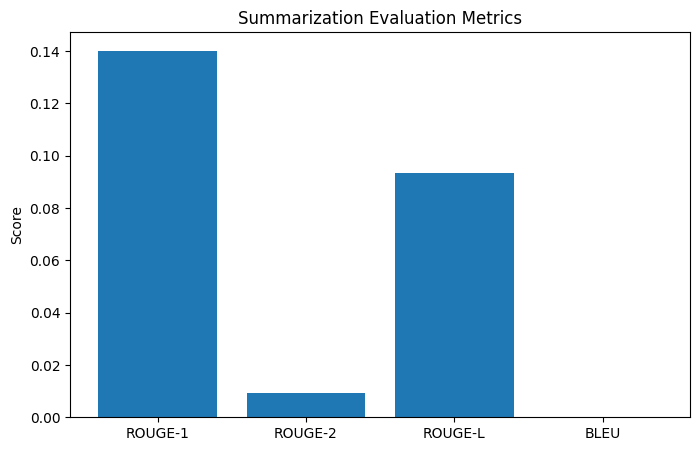

In [36]:
import matplotlib.pyplot as plt

# metric values
metric_names = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BLEU"]
metric_values = [
    rouge_results["rouge1"],
    rouge_results["rouge2"],
    rouge_results["rougeL"],
    bleu_results["bleu"]
]

# create chart
plt.figure(figsize=(8, 5))
plt.bar(metric_names, metric_values)

plt.title("Summarization Evaluation Metrics")
plt.ylabel("Score")

plt.show()

##Evaluation Insights

- ROUGE scores are relatively low, indicating weak similarity between the generated and reference articles.
- BLEU score reached 0.0, showing that the generated text differs significantly from the expected output.
- Manual inspection confirmed that the fine-tuned model often copied noisy complaint text instead of generating structured recommendations.
- The small fine-tuning dataset (only a few examples) limited the model’s ability to generalize.
- In this project, n-shot prompting produced more reliable results than fine-tuning with a very small dataset.

## Failure Cases and Iteration Tracking

### Initial Generator Output
- The first generator outputs contained hallucinations and reused example product names.
- Some responses included products or features not present in the input data.

### Prompt Engineering Improvements
- Adding stricter prompt rules improved factual consistency.
- N-shot prompting improved article structure and recommendation quality.
- Simpler examples reduced unwanted copying behavior.

### Fine-Tuning Experiment
- Fine-tuning FLAN-T5 Small on a very small dataset produced weak results.
- The model often copied noisy complaint text directly from the input.
- Evaluation metrics (ROUGE/BLEU) confirmed weak generation quality.

### Best Performing Approach
- Qwen 1.5B with n-shot prompting produced the most reliable and readable recommendation articles.
- Prompt engineering proved more effective than small-scale fine-tuning in this project.

### Lessons Learned
- Generative AI models require high-quality training examples and careful prompt design.
- Small datasets are often insufficient for reliable fine-tuning.
- Manual inspection is important because automatic metrics alone cannot fully capture output quality.

##Final Conclusions

- The project successfully demonstrates an end-to-end NLP pipeline for analyzing customer reviews.

- The sentiment classifier (DistilBERT) achieved strong performance (~95% accuracy), although dataset imbalance affected the detection of neutral reviews.

- The clustering approach (MiniLM embeddings + KMeans) revealed meaningful product groupings. While the silhouette score was relatively low, manual inspection confirmed useful thematic clusters.

- The summarization pipeline explored multiple generation approaches, including zero-shot prompting, n-shot prompting, and fine-tuning.

- Qwen 1.5B combined with n-shot prompting produced the most reliable and structured recommendation articles.

- Fine-tuning FLAN-T5 Small on a very small dataset resulted in weak generation quality, demonstrating that generative models require larger and higher-quality datasets for effective fine-tuning.

- ROUGE and BLEU evaluation metrics confirmed the limitations of the fine-tuned model, while manual inspection highlighted issues such as hallucinations and noisy text copying.

- Prompt engineering proved to be highly important for improving factual consistency and output structure in generative AI systems.

- Overall, combining classification, clustering, and generation transformed raw customer reviews into meaningful business insights and recommendation summaries.

- Limitations of the project include dataset imbalance, noisy review text, limited fine-tuning data, and the inherent challenges of unsupervised clustering and generative AI reliability.